In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

from scipy.signal import correlate2d, convolve2d
from scipy.interpolate import RegularGridInterpolator

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


# Effects of different phase cube densities on pattern

**Moving completely to thin lens modeling**

*Finding: around half the region covered with cubes given the smallest pixel size*

* ~~Ensuring proper sampling, wavefield size, and boundary conditions~~
* *Simulate and save phase mask with proper sizes*
    * *Try different densities of structures*
    * ~~Compare outputs from different samplings~~
* Ensure proper simulation w.r.t. medium RIs
* C~~ompare BPM vs Thin sample modeling~~
    * ~~Make videos for propagation distances~~
* Problem specification: FOV and same sampling, but spatial resolution/ spatial frequency limited by distance and speckle size?
    * ~~Speckle size increases with distance?~~
* Averaging opoerator with stride to map output onto sensor pixels
* Finding minimum sampling frequency: Confirm when sampling frequency starts to effect output

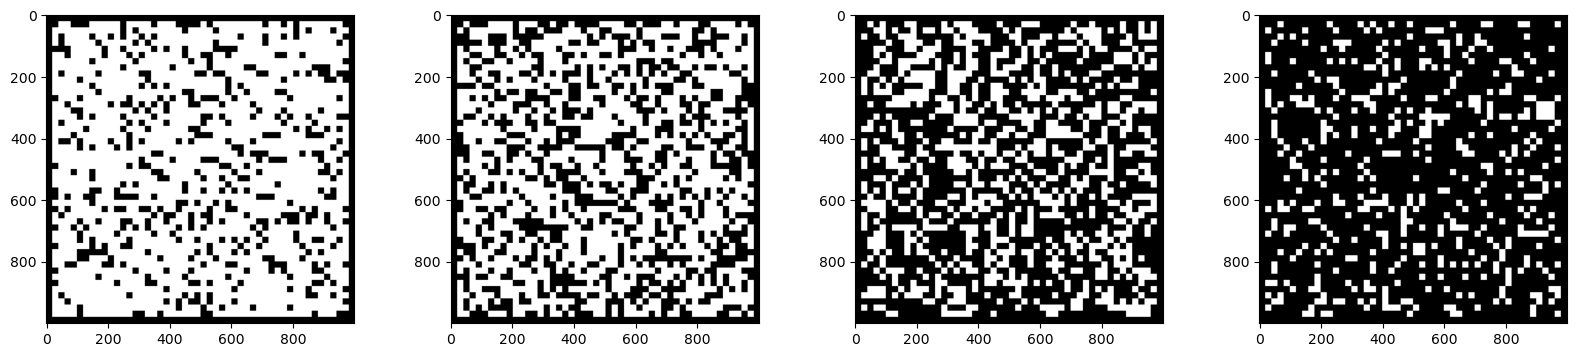

In [2]:
# create phase mask:

# Grid and propagation parameters setup
wl = 640e-9
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 1000 # nx == ny
side_length = 10e-6

tile_size = int(side_length/dx)

h_map_1 = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, 250e-9, prob=0.2)
h_map_2 = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, 250e-9, prob=0.4)
h_map_3 = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, 250e-9, prob=0.6)
h_map_4 = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, 250e-9, prob=0.8)

fig, axs = plt.subplots(1, 4, figsize=(20, 4))

axs[0].imshow(h_map_1, cmap='gray')
axs[1].imshow(h_map_2, cmap='gray')
axs[2].imshow(h_map_3, cmap='gray')
axs[3].imshow(h_map_4, cmap='gray')

plt.show()

t = h_map_1.max()
RI = np.ones_like(h_map_1)*1.46

field = np.zeros([nx, nx])
field[:, :] = 10

phase_delay_1 = np.exp(-1j*(2*np.pi/wl)*(h_map_1*RI + (t-h_map_1)*n_0))
phase_delay_2 = np.exp(-1j*(2*np.pi/wl)*(h_map_2*RI + (t-h_map_2)*n_0))
phase_delay_3 = np.exp(-1j*(2*np.pi/wl)*(h_map_3*RI + (t-h_map_3)*n_0))
phase_delay_4 = np.exp(-1j*(2*np.pi/wl)*(h_map_4*RI + (t-h_map_4)*n_0))

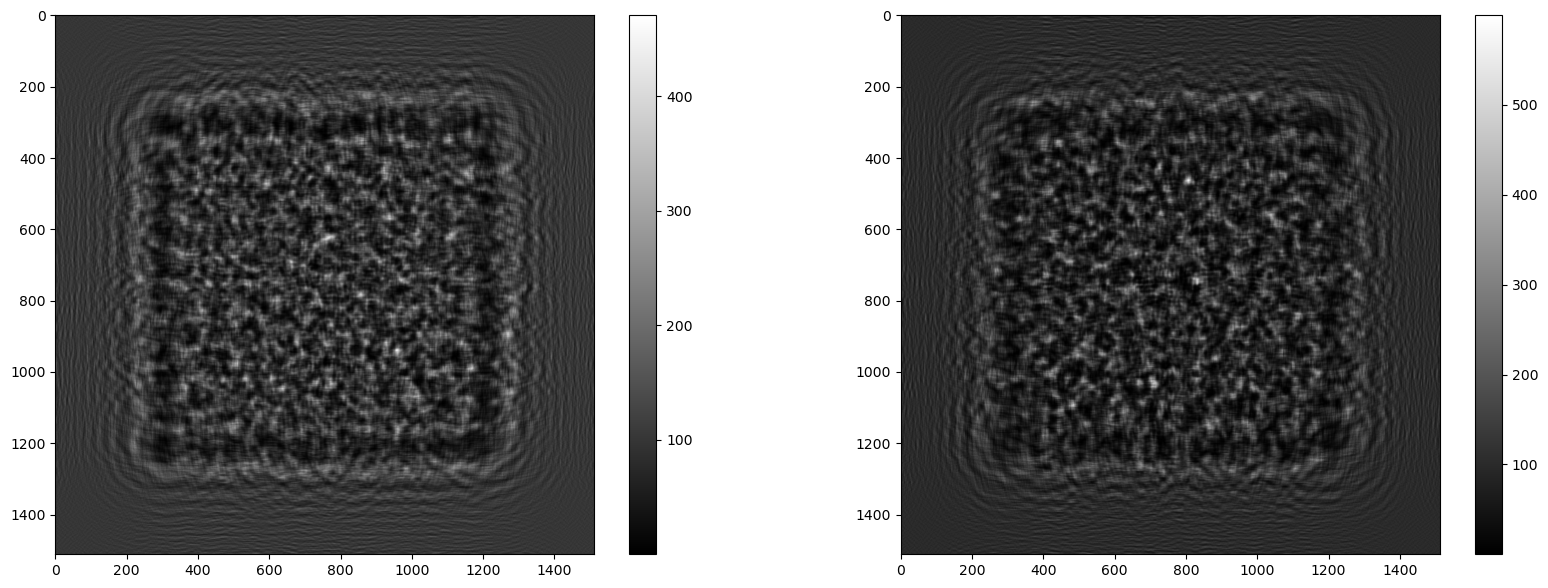

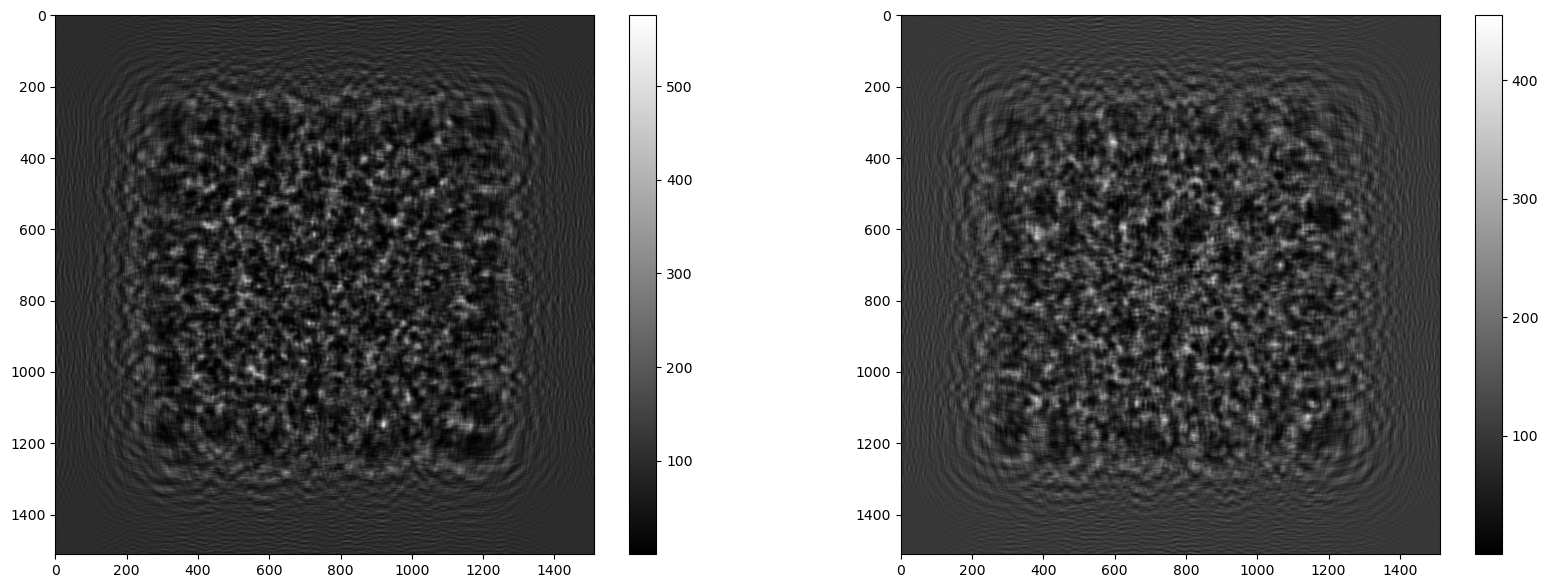

In [3]:
output_field_1 = propagator.propagate(np.pad(field*phase_delay_1, 256, 'edge'), wl/1.49, [dx, dx], 3.e-3, padding=None)
output_field_2 = propagator.propagate(np.pad(field*phase_delay_2, 256, 'edge'), wl/1.49, [dx, dx], 3.e-3, padding=None)
output_field_3 = propagator.propagate(np.pad(field*phase_delay_3, 256, 'edge'), wl/1.49, [dx, dx], 3.e-3, padding=None)
output_field_4 = propagator.propagate(np.pad(field*phase_delay_4, 256, 'edge'), wl/1.49, [dx, dx], 3.e-3, padding=None)


fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field_1)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_2)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field_3)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_4)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

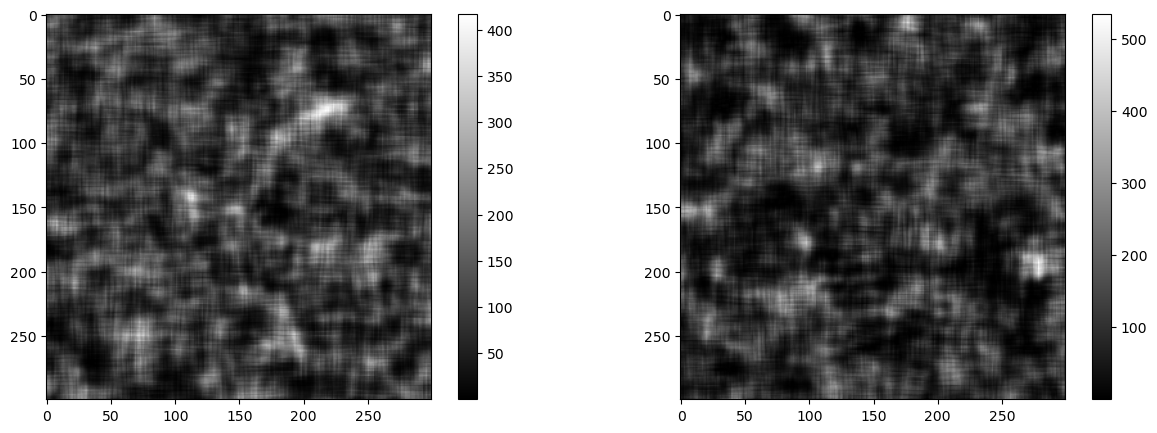

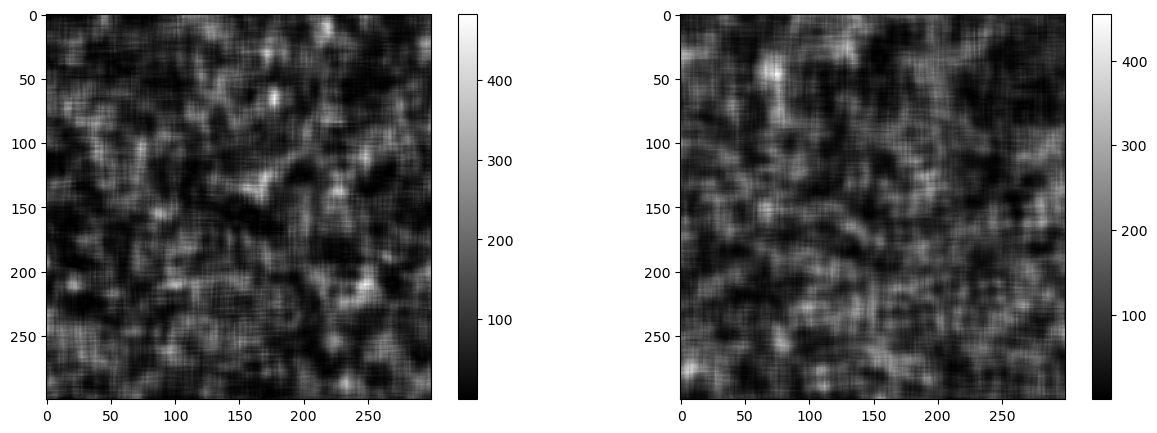

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

z1_patch = output_field_1[550:850, 550:850]
z2_patch = output_field_2[550:850, 550:850]
z3_patch = output_field_3[550:850, 550:850]
z4_patch = output_field_4[550:850, 550:850]

cm0 = axs[0].imshow(np.abs(z1_patch)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(z2_patch)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(np.abs(z3_patch)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(z4_patch)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

In [5]:
corr_z1 = correlate2d(np.abs(z1_patch)**2, np.abs(z1_patch)**2)
corr_z2 = correlate2d(np.abs(z2_patch)**2, np.abs(z2_patch)**2)
corr_z3 = correlate2d(np.abs(z3_patch)**2, np.abs(z3_patch)**2)
corr_z4 = correlate2d(np.abs(z4_patch)**2, np.abs(z4_patch)**2)

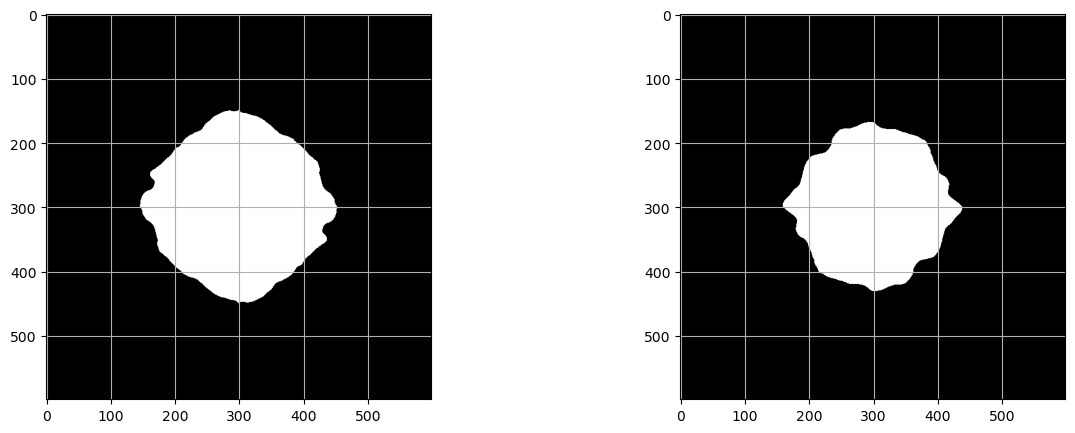

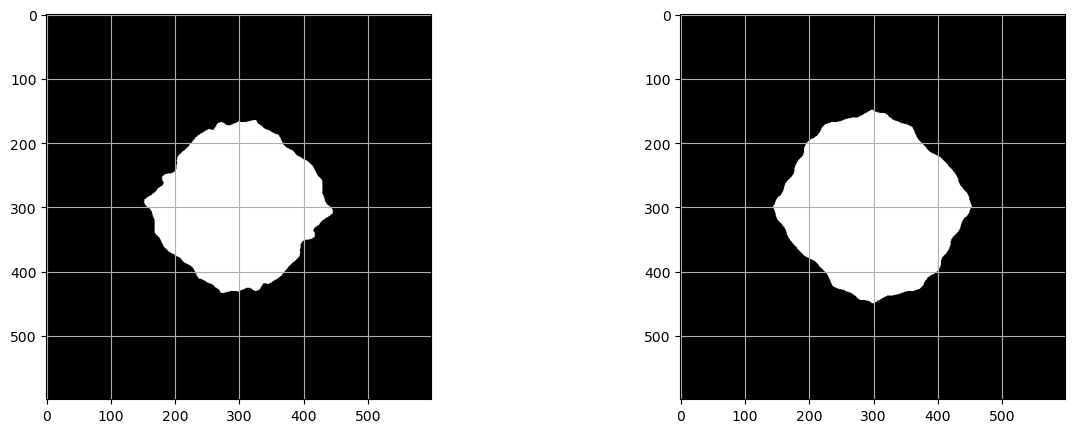

61109
48635
51507
61051


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(corr_z1/corr_z1.max() > np.exp(-1), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(corr_z2/corr_z2.max() > np.exp(-1), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])


plt.show()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(corr_z3/corr_z3.max() > np.exp(-1), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(corr_z4/corr_z4.max() > np.exp(-1), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])


plt.show()

print(np.sum(corr_z1/corr_z1.max() > np.exp(-1)))
print(np.sum(corr_z2/corr_z2.max() > np.exp(-1)))
print(np.sum(corr_z3/corr_z3.max() > np.exp(-1)))
print(np.sum(corr_z4/corr_z4.max() > np.exp(-1)))

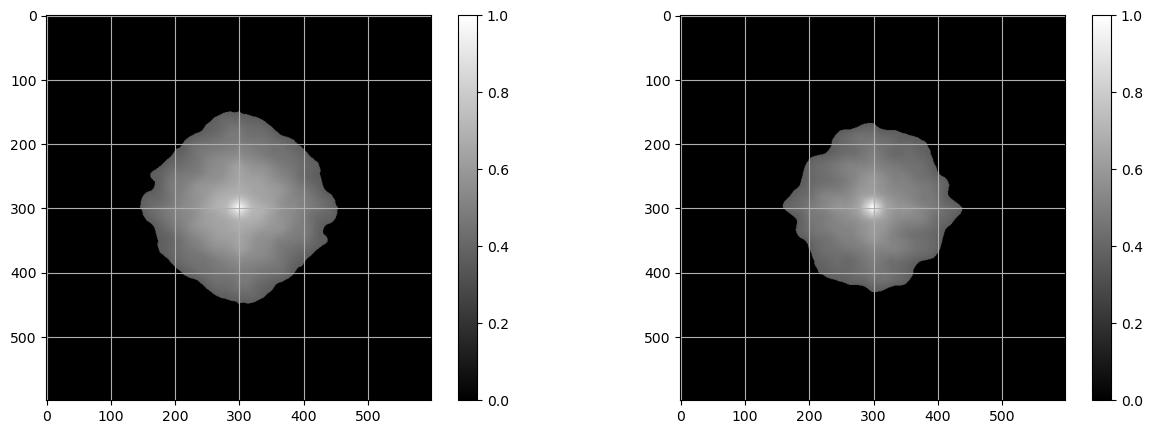

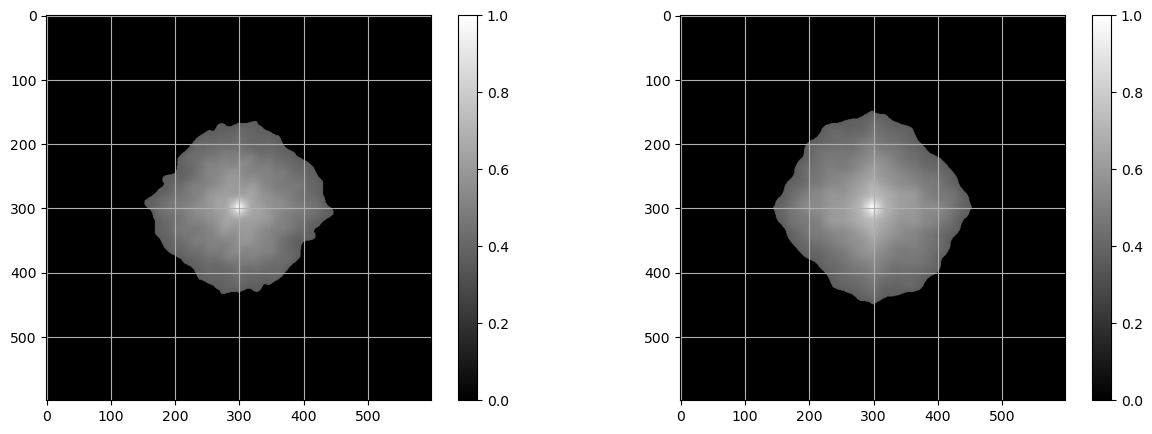

30653.902046344076
23019.0096781669
24567.19478910976
30153.212305652803


In [8]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(np.where(corr_z1/corr_z1.max() > np.exp(-1), 
                             corr_z1/corr_z1.max(), 0), cmap='gray')
axs[0].grid()
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.where(corr_z2/corr_z2.max() > np.exp(-1), 
                             corr_z2/corr_z2.max(), 0), cmap='gray')
axs[1].grid()
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(np.where(corr_z3/corr_z3.max() > np.exp(-1), 
                             corr_z3/corr_z3.max(), 0), cmap='gray')
axs[0].grid()
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.where(corr_z4/corr_z4.max() > np.exp(-1), 
                             corr_z4/corr_z4.max(), 0), cmap='gray')
axs[1].grid()
plt.colorbar(cm1, ax=axs[1])

plt.show()

print(np.sum(np.where(corr_z1/corr_z1.max() > np.exp(-1), corr_z1/corr_z1.max(), 0)))
print(np.sum(np.where(corr_z2/corr_z2.max() > np.exp(-1), corr_z2/corr_z2.max(), 0)))
print(np.sum(np.where(corr_z3/corr_z3.max() > np.exp(-1), corr_z3/corr_z3.max(), 0)))
print(np.sum(np.where(corr_z4/corr_z4.max() > np.exp(-1), corr_z4/corr_z4.max(), 0)))

In [1]:
# cap = cv2.VideoCapture(0)

# # Define the codec and create VideoWriter object
# #fourcc = cv2.cv.CV_FOURCC(*'DIVX')
# #out = cv2.VideoWriter('output.avi',fourcc, 20.0, (640,480))
# out = cv2.VideoWriter('v9/v9_3/10um_250nm_2_mask_prop_abs.avi', cv2.VideoWriter_fourcc(*'XVID'), 20, (200, 200), isColor=False)

# for i in range(1, 3000, 10):
#     frame = propagator.propagate(field*phase_delay, wl/1.49, [dx, dx], i*1e-6, padding=256)
    
#     frame = np.abs(frame)**2
#     # frame = convolve2d(frame, np.ones([10, 10]), mode='valid')[::10, ::10]
#     frame = np.array(((frame - frame.min())/(frame.max() - frame.min()))*255, dtype=np.uint8)

#     # write the flipped frame
#     out.write(frame)

# # Release everything if job is finished
# out.release()